In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier,plot_tree #arbol de decision y ploteo
from sklearn.model_selection import train_test_split #herramienta de corte de dataset
from sklearn.metrics import ConfusionMatrixDisplay #matriz de confusión
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, poisson
import matplotlib.pyplot as plt

In [2]:
datos = pd.read_csv("../datos/whisky.csv") #levantamos el archivo a un dataframe

In [3]:
datos.head()

,id_Whisky,Precio,Malta,Categoria,Anejamiento,Calidad
0,1,70,20,Lujo,5.0,3
1,2,60,20,Lujo,5.0,2
2,3,65,20,Lujo,7.5,2
3,4,74,25,Lujo,12.0,2
4,5,70,25,Lujo,12.0,3


In [4]:
datos.drop('id_Whisky',inplace=True,axis=1) #eliminamos columna id_whisky


In [5]:
datos.head()

,Precio,Malta,Categoria,Anejamiento,Calidad
0,70,20,Lujo,5.0,3
1,60,20,Lujo,5.0,2
2,65,20,Lujo,7.5,2
3,74,25,Lujo,12.0,2
4,70,25,Lujo,12.0,3


In [6]:
#variables predictoras (Precio,Malta, categoria,Anejamiento) y una variable objetivo (Calidad)
columnas = datos.columns.values.tolist()

In [7]:
columnas

['Precio', 'Malta', 'Categoria', 'Anejamiento', 'Calidad']

In [8]:
prediccion = columnas[:4] #columnas de 0 al 3
objetivo=columnas[4]
prediccion

['Precio', 'Malta', 'Categoria', 'Anejamiento']

In [9]:
objetivo

'Calidad'

In [10]:
from sklearn.preprocessing import LabelEncoder
numerizacion=LabelEncoder()
datos['Categoria']=numerizacion.fit_transform(datos['Categoria'])

In [11]:
datos

,Precio,Malta,Categoria,Anejamiento,Calidad
0,70,20,1,5.0,3
1,60,20,1,5.0,2
2,65,20,1,7.5,2
3,74,25,1,12.0,2
4,70,25,1,12.0,3
5,73,30,1,5.0,0
6,70,30,1,8.0,0
7,55,30,1,5.0,2
8,77,30,1,5.5,0
9,93,30,1,12.0,0


# datos de entrenamiento y de validación

In [27]:
x_train,x_test,y_train,y_test= train_test_split(datos[prediccion],datos[objetivo],test_size=0.30,random_state=56)

In [28]:
y_test

7     2
25    4
13    3
8     0
3     2
20    2
24    2
19    4
34    0
16    2
10    2
Name: Calidad, dtype: int64

In [29]:
arbol = DecisionTreeClassifier(criterion="entropy",min_samples_split=5,random_state=40)

In [30]:
arbol

DecisionTreeClassifier(criterion='entropy', min_samples_split=5,
                       random_state=40)

In [31]:
arbol.fit(x_train,y_train) #entrenamiento

DecisionTreeClassifier(criterion='entropy', min_samples_split=5,
                       random_state=40)

In [32]:
predics = arbol.predict(x_test) #prediccion

In [33]:
predics

array([0, 3, 2, 0, 2, 1, 1, 1, 3, 1, 0], dtype=int64)

In [34]:
y_test

7     2
25    4
13    3
8     0
3     2
20    2
24    2
19    4
34    0
16    2
10    2
Name: Calidad, dtype: int64

In [20]:
#matriz de confusión con pandas

In [35]:
pd.crosstab(y_test,predics,rownames=["Real"],colnames=["Prediccion"])

Prediccion,0,1,2,3
Real,,,,
0,1,0,0,1
2,2,3,1,0
3,0,0,1,0
4,0,1,0,1


In [22]:
#matriz de confusión con el plot

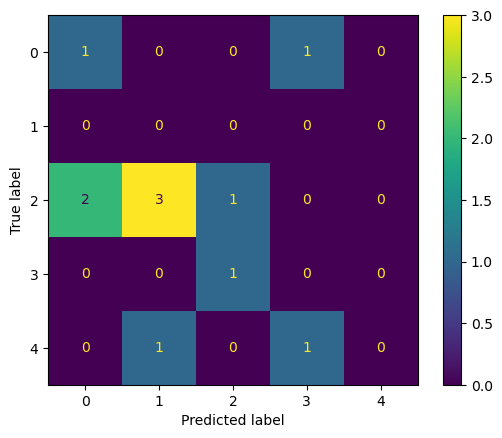

In [36]:
ConfusionMatrixDisplay.from_estimator(arbol,x_test,y_test)
plt.show()

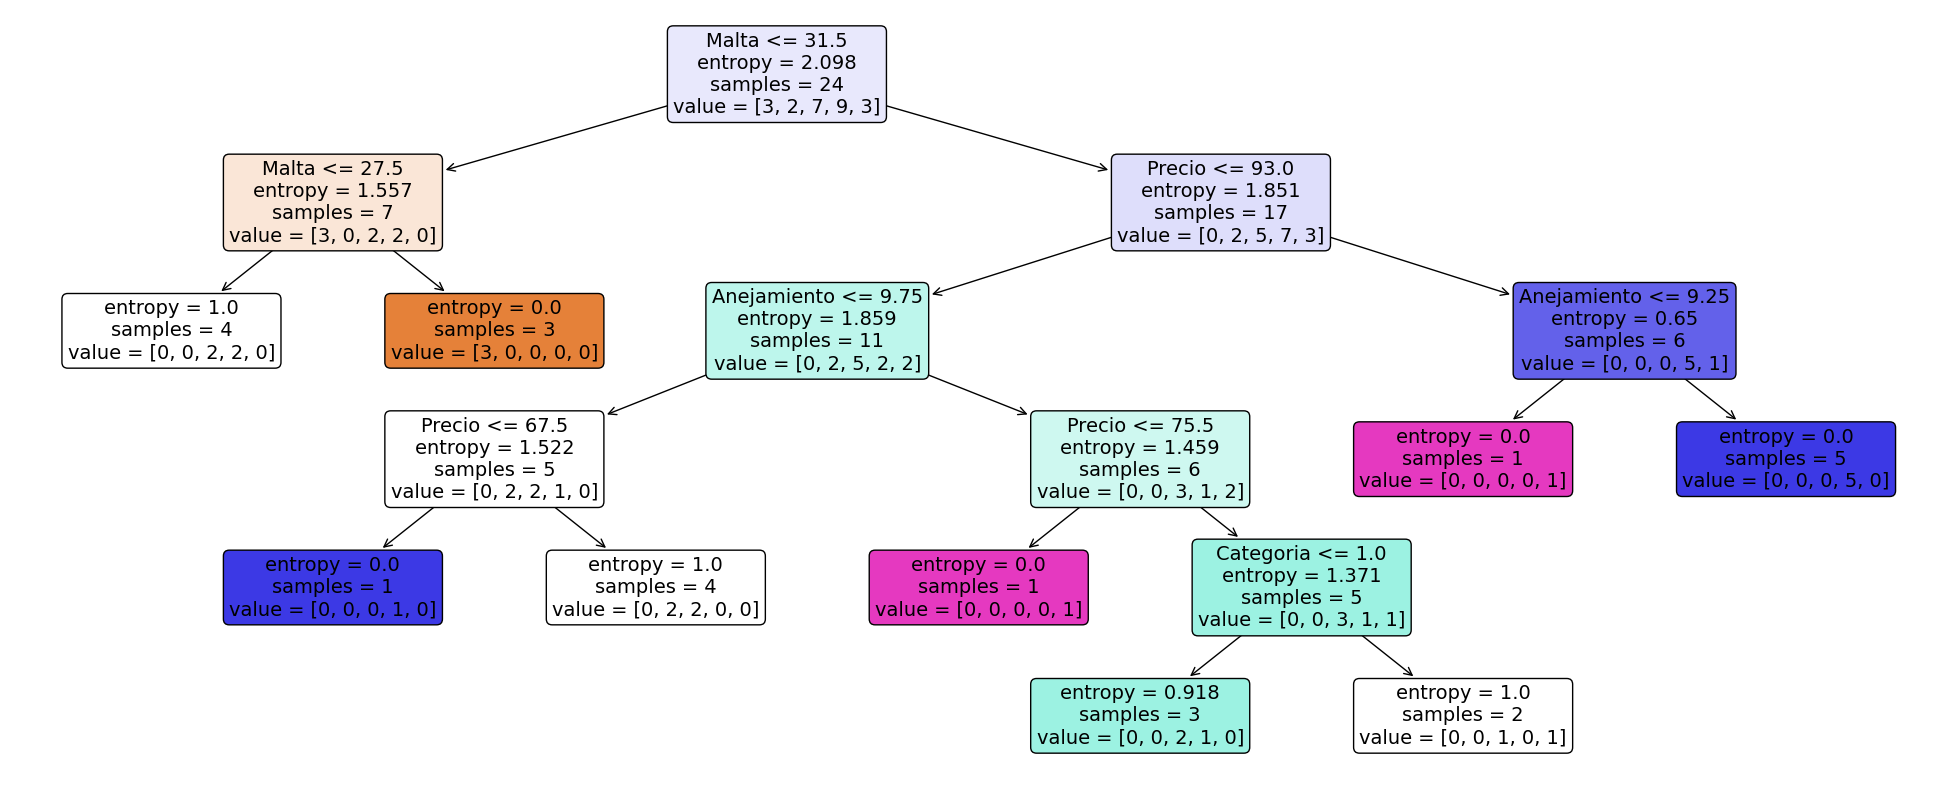

In [37]:
plt.figure(figsize=(25,10))
a= plot_tree(arbol,
             feature_names=prediccion,
             class_names=None,
             filled=True,
             rounded=True,
             fontsize=14)

In [39]:
# setup parameter space
parameters = {'max_depth':poisson(mu=2,loc=2),
              'max_leaf_nodes':poisson(mu=5,loc=5),
              'min_samples_split':uniform(),
              'min_samples_leaf':uniform()}

# create an instance of the randomized search object
rsearch = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), 
                             parameters, cv=4, n_iter=100, random_state=42)

# conduct randomised search over the parameter space
rsearch.fit(x_train,y_train)

C:\Users\danie\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:725: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=4.
  warnings.warn(


RandomizedSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=100,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002061E8C9390>,
                                        'max_leaf_nodes': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002061787AE90>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000020617836010>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002061D991750>},
                   random_state=42)

In [40]:
# show best parameter configuration found for classifier
cls_params = rsearch.best_params_
cls_params['min_samples_split'] = np.ceil(cls_params['min_samples_split']*x_train.shape[0])
cls_params['min_samples_leaf'] = np.ceil(cls_params['min_samples_leaf']*x_train.shape[0])
cls_params

{'max_depth': 6,
 'max_leaf_nodes': 9,
 'min_samples_leaf': 1.0,
 'min_samples_split': 24.0}

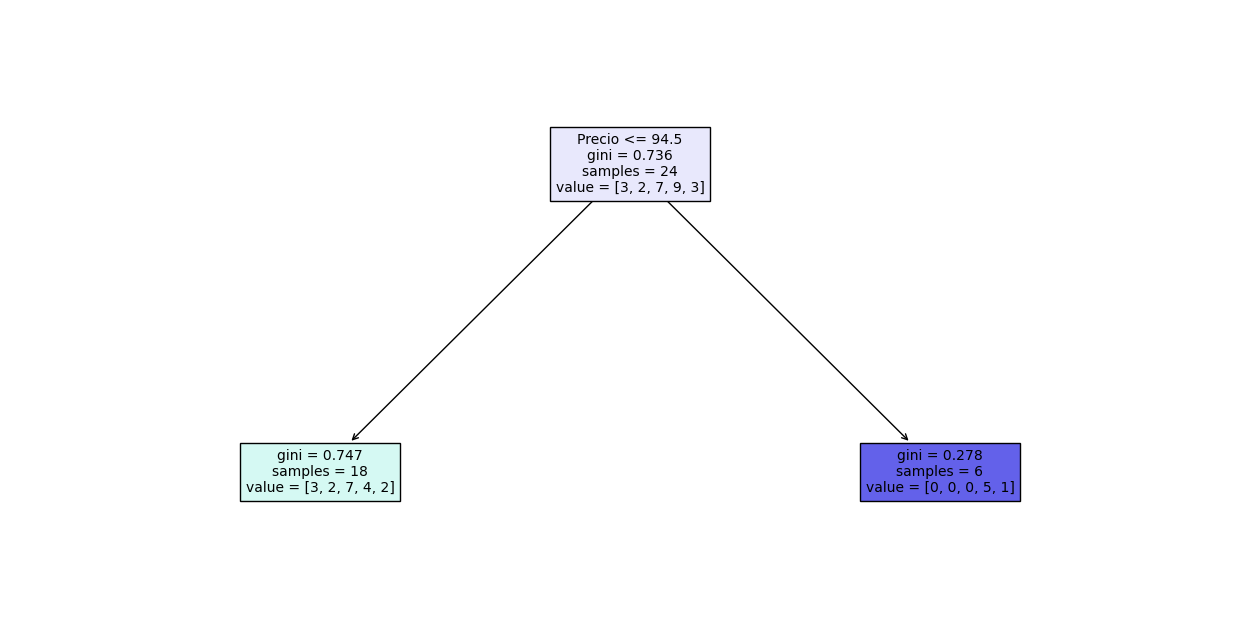

In [41]:
# extract best classifier
clf = rsearch.best_estimator_

# visualise the decision tree
fig = plt.figure(figsize=(16,8))
_ = plot_tree(clf, 
              feature_names=prediccion,
              filled=True,
              class_names=None,
              fontsize=10)